<a href="https://colab.research.google.com/github/NITTALOKESH/MLA0204-FUNDAMENTALS-OF-MEACHINE-LEARNINGS--NITTA-LOKESH/blob/main/program%20no%203%20play%20tennis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset:
     Outlook Temperature Humidity    Wind Play
0      Sunny         Hot     High    Weak   No
1      Sunny         Hot     High  Strong   No
2   Overcast         Hot     High    Weak  Yes
3       Rain        Mild     High    Weak  Yes
4       Rain        Cool   Normal    Weak  Yes
5       Rain        Cool   Normal  Strong   No
6   Overcast        Cool   Normal  Strong  Yes
7      Sunny        Mild     High    Weak   No
8      Sunny        Cool   Normal    Weak  Yes
9       Rain        Mild   Normal    Weak  Yes
10     Sunny        Mild   Normal  Strong  Yes
11  Overcast        Mild     High  Strong  Yes
12  Overcast         Hot   Normal    Weak  Yes
13      Rain        Mild     High  Strong   No


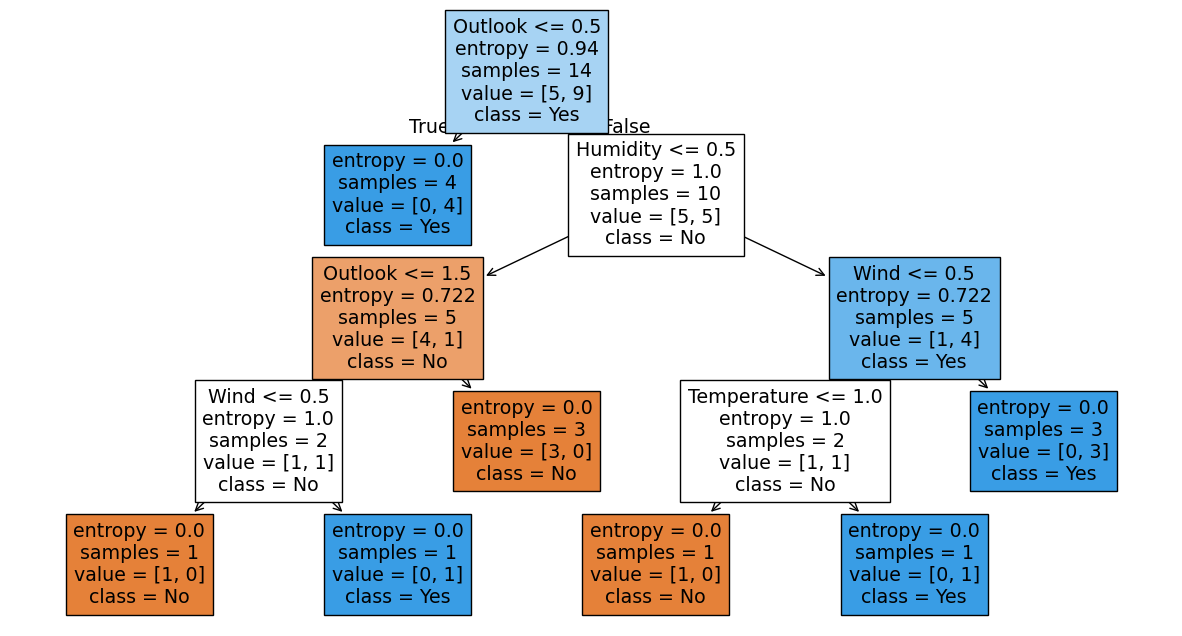

New Sample:
Outlook = Sunny, Temperature = Cool, Humidity = Normal, Wind = Strong
Prediction: No


In [1]:
# Decision Tree using ID3 Algorithm

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Dataset
data = {
    'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast',
                'Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool',
                    'Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal',
                 'High','Normal','Normal','Normal','High','Normal','High'],
    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong','Strong',
             'Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'Play': ['No','No','Yes','Yes','Yes','No','Yes',
             'No','Yes','Yes','Yes','Yes','Yes','No']
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

# Convert text values into numbers
encoders = {}

for column in df.columns:
    encoders[column] = LabelEncoder()
    df[column] = encoders[column].fit_transform(df[column])

# Separate input and output
X = df.drop('Play', axis=1)
y = df['Play']

# Create ID3 Decision Tree
model = DecisionTreeClassifier(criterion='entropy', random_state=0)

# Train the model
model.fit(X, y)

# Display tree
plt.figure(figsize=(15, 8))
plot_tree(model,
          feature_names=X.columns,
          class_names=encoders['Play'].classes_,
          filled=True)
plt.show()

# New sample
new_sample = pd.DataFrame([{
    'Outlook': 'Sunny',
    'Temperature': 'Cool',
    'Humidity': 'Normal',
    'Wind': 'Strong'
}])

# Encode new sample
for column in new_sample.columns:
    new_sample[column] = encoders[column].transform(new_sample[column])

# Predict
prediction = model.predict(new_sample)

# Convert prediction back to original value
result = encoders['Play'].inverse_transform(prediction)

print("New Sample:")
print("Outlook = Sunny, Temperature = Cool, Humidity = Normal, Wind = Strong")

print("Prediction:", result[0])